### Importações

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

### Carrega dataset

In [2]:
df = pd.read_parquet("../data/processed/flights_processed.parquet")

In [ ]:
pd.set_option('display.max_columns', None) 
df.head()

### Padronização

In [3]:
continuous_features = ["SCHEDULED_TIME", "DISTANCE", "SCHEDULED_ARRIVAL", "MONTH", "HOUR", "DAY_OF_WEEK"]
scaler = StandardScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])

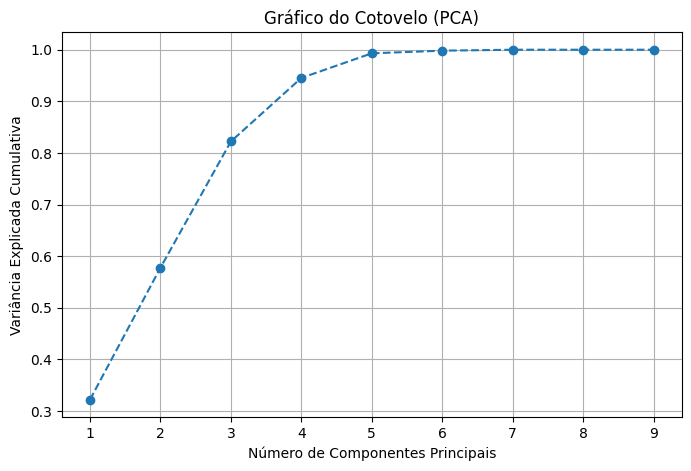

In [8]:
features = ["SCHEDULED_TIME", "DISTANCE", "SCHEDULED_ARRIVAL", "MONTH", "HOUR", "DAY_OF_WEEK", "IS_LONG_DISTANCE", "HOUR", "DAY_OF_WEEK"]
X = df[features]

# Criar PCA para todos os componentes
pca = PCA()
pca.fit(X)

# Variância explicada cumulativa
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Plot do cotovelo
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Cumulativa')
plt.title('Gráfico do Cotovelo (PCA)')
plt.grid(True)
plt.show()

In [11]:
# Supondo que X já esteja padronizado
pca = PCA(n_components=2)
pca.fit(X)

# Mostrar variância explicada
print("Variância explicada pelos componentes:", pca.explained_variance_ratio_)

# Mostrar os pesos de cada variável em cada componente
componentes = pd.DataFrame(pca.components_, columns=X.columns, index=['PC1', 'PC2'])
print(componentes)

Variância explicada pelos componentes: [0.32178426 0.25559187]
     SCHEDULED_TIME  DISTANCE  SCHEDULED_ARRIVAL     MONTH      HOUR  \
PC1        0.003075  0.005415           0.524308 -0.003501  0.601671   
PC2        0.641678  0.642388           0.012431  0.009132 -0.020374   

     DAY_OF_WEEK  IS_LONG_DISTANCE      HOUR  DAY_OF_WEEK  
PC1     0.022658          0.002774  0.601671     0.022658  
PC2     0.266555          0.180044 -0.020374     0.266555  


* PC1 = 0.3218  (32%) (HOUR ≈ 0.60 e SCHEDULED_ARRIVAL ≈ 0.52)
* PC2 = 0.2556  (25%) (SCHEDULED_TIME ≈ 0.64 e SCHEDULED_TIME ≈ 0.64)


